In [12]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.special import erf
import os

Generating the potential profile used

In [4]:
# We can describe it as a function
def E_t(E1,E2,nu,t):
    """
    It is a function that giving a time gives 
    the potential following a cyclic voltammetry 
    potential profile

    Args:
        - E1: Initial Potential (mV)
        - E2: Final Potential (mV)
        - nu: The Scan rate (mV/s)
        - t: Time (s)

    Return:
        - E: Potential (mV)
    """
    # Define the limit time to have one or another
    ts = abs(E2 - E1)/nu
    # See in which moment it is
    if t%(2*ts)<ts:
        return E1 + np.sign(E2-E1)*nu * (t%(2*ts))
    return E2 -np.sign(E2-E1)* nu * (t%(2*ts) - ts)

In [2]:
def Simulate(nus=np.array([1,5,10,20,30,40,50,60])*10**(-3),E1=-0.55,E2=0.55,
             DA = 1e-5,DB = 1e-5,alpha = 0.5,F = 96485.3,R = 8.314,T = 298,k0 = 1e-2,E0 = 0.,n = 1,A = 1,
             CA0_=0,CB0_=1e-3):
    """
    Simulate the cyclic voltammetry using Butler-Volmer kinetics and Fick's second law for diffusion. 
    It calculates the Faradaic, Capacitive, and Total currents for a range of scan rates.

    Args:
        - nus: The scan rates (mV/s)
        - E1: Initial Potential (mV)
        - E2: Final Potential (mV)
        - DA: Diffusion coefficient of A (cm^2/s)
        - DB: Diffusion coefficient of B (cm^2/s)
        - alpha: Charge transfer coefficient
        - F: Faraday's constant (C/mol)
        - R: Gas constant (J/(mol*K))
        - T: Temperature (K)
        - k0: Standard rate constant (cm/s)
        - E0: Standard potential (mV)
        - n: Number of electrons transferred
        - A: Electrode area (cm^2)
        - CA0_: Initial concentration of A (mol/cm^3)
        - CB0_: Initial concentration of B (mol/cm^3)
    Return:
        - ETs: List of potentials for each scan rate
        - JSf: List of Faradaic currents for each scan rate
        - JSc: List of Capacitive currents for each scan rate
        - JST: List of Total currents for each scan rate
    """
    
    Nj = 100# Size of the space
    dx = 0.0014 # variation of space in cm
    dt = 0.05 # variation of time in s
    x = np.arange(0,Nj*dx , dx)
    ETs = []
    JSf = []
    JSc = []
    JST = []
    # Defining the limit time
    for i in range(len(nus)):
        nu = nus[i]
        ts = abs(E1-E2)/nu # time to change direction
        t = np.arange( 100*dt*0,2*ts,dt)
        Nt = len(t) # Size of the time

        Et = np.array([E_t(E1,E2,nu,ti) for ti in t]) # The potential for each second

        # Define reaction variables
        kc = k0* np.exp( -(alpha * F)/(R*T) * (Et - E0)  )
        ka = k0* np.exp( ((1-alpha) * F)/(R*T) * (Et - E0)  )

        CA0 = CA0_*np.ones_like(x)
        CB0 = CB0_*np.ones_like(x)
        # Let's calculate the Concentration for each point for each time
        CAs = []
        CAs.append(CA0)
        CBs = []
        CBs.append(CB0)


        CBs[-1][0] = abs((kc[0] *(CAs[-1][1] + DB/DA*CBs[-1][1]) + CBs[-1][1]* DB/(dx) )/(DB/dx + ka[0] + kc[0]*DB/(DA) ))
        CAs[-1][0] = abs(CAs[-1][1] + DB/DA * (CBs[-1][1] - CBs[-1][0]))


        # Now let's apply it for every second
        for i in range(0,len(t)-1):
            Ca = CAs[-1].copy()
            Cb = CBs[-1].copy()

        
            laplacian_A = ( (CAs[i][2:].copy() - 2*CAs[i][1:-1].copy() + CAs[i][:-2].copy()) / dx**2  )
            laplacian_B = ( (CBs[i][2:].copy() - 2*CBs[i][1:-1].copy() + CBs[i][:-2].copy()) / dx**2    )

            Ca[1:-1] += DA * dt * laplacian_A
            Cb[1:-1] += DB * dt * laplacian_B


            Cb[0] = ((kc[i] *(Ca[1] + DB/DA*Cb[1]) + Cb[1]* DB/(dx) )/(DB/dx + ka[i] + kc[i]*DB/(DA) ))
            Ca[0] = (Ca[1] + DB/DA * (Cb[1] - Cb[0]))


            CAs.append(Ca)
            CBs.append(Cb)
        # Now let's calculate the flux for each time
        Js = np.array([-kc[i]*CAs[i][0] + ka[i]*CBs[i][0] for i in range(len(t))]) #* n*A*F

        # Potentials values 'Et' variable
        J_far = Js*n*A*F

        # Parameters
        C_dl = 8  # Capacitance (F)
        R_s = 0.05     # Resistance (Ohm)
        tau = R_s * C_dl

        # Defining the limit time
        E1c = -0.55 # Potential V
        E2c = 0.55 # Potential V
        tsc = abs(E1c-E2c)/nu # time to change direction
        tc = np.arange( 100*dt*0,2*tsc,dt)

        Etc = np.array([E_t(E1c,E2c,nu,ti) for ti in tc]) # The potential for each second

        # Assuming Et and t are already defined from your Faradaic simulation
        # We need to find the index where the scan reverses
        idx_reverse = np.argmax(Etc) 

        # Initialize J_cap array
        J_cap = np.zeros_like(tc)

        # Forward Scan (Charging)
        t_fwd = tc[:idx_reverse]
        J_cap[:idx_reverse] = nu * C_dl * (1 - np.exp(-t_fwd / tau))

        # Reverse Scan (Discharging / Reversing polarity)
        # We reset 't' for the exponential decay starting from the switching point
        t_rev = tc[idx_reverse:] - tc[idx_reverse]
        # Note the sign change (-nu) and the shift from the previous steady state
        J_cap[idx_reverse:] = -nu * C_dl + (J_cap[idx_reverse-1] + nu * C_dl) * np.exp(-t_rev / tau)

        # Total Current
        J_total = J_far + 2*J_cap

        JSc.append(2*J_cap)
        JST.append(J_total)
        ETs.append(Et)
        JSf.append(J_far)

    return ETs,JSf,JSc,JST
        

In [5]:
nus = np.array([10,20,30,40,50])*10**(-3)

Et,If,Ic,It = Simulate(nus=nus,E1=-0.55,E2=0.55,
             DA = 1e-5,DB = 1e-5,alpha = 0.5,F = 96485.3,R = 8.314,T = 298,k0 = 1e-2,E0 = 0.,n = 1,A = 1,
             CA0_=0,CB0_=1e-3)

Let's see the shape of the curves

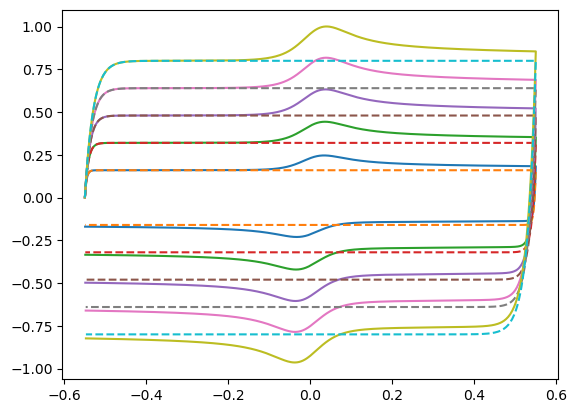

In [6]:
for i in range(len(nus)):
    plt.plot(Et[i],It[i])
    plt.plot(Et[i],Ic[i],'--')

Let's just adjust the data positions so that they are correctly spaced

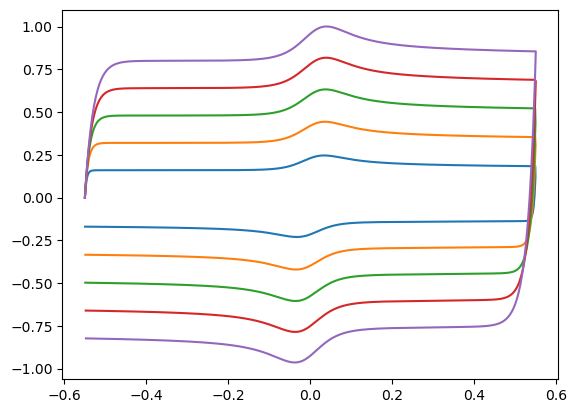

In [9]:
# Let's define a ideal number of points per cycle to be the ideal
n_aligned = 1000 
# Let's create an array that allow the data to go from 0 to 1 (0% to 100% of scan time)
p_commum = np.linspace(0, 1, n_aligned)

Et_align = []
It_align = []

for i in range(len(nus)):

    p_now = np.linspace(0, 1, len(Et[i]))
    
    # Interpolate the Potential and Current to the p_commum
    # This ensures that the point 500 of all lists is exactly the peak (E2)
    E_interp = np.interp(p_commum, p_now, Et[i])
    I_interp = np.interp(p_commum, p_now, It[i])
    
    Et_align.append(E_interp)
    It_align.append(I_interp)


Et_align = np.array(Et_align)
It_align = np.array(It_align)

# Just to see data
for i in range(len(nus)):
    plt.plot(Et_align[i], It_align[i], label=f'{nus[i]*1000:.0f} mV/s')

Save data

In [ ]:
direc = 'Data'
os.makedirs(direc, exist_ok=True)

for i in range(len(nus)):

    with open(f'{direc}/VC_{nus[i]*1000:.0f}mVps.txt', 'w') as f:
        f.write('Potential (V);Current (A)\n')
        for e, it in zip(Et_align[i], It_align[i]):
            f.write(f"{e};{it}\n")


Save the ideal data

In [18]:
direc = 'Data/ideal'
os.makedirs(direc, exist_ok=True)

for i in range(len(nus)):

    with open(f'{direc}/VC_{nus[i]*1000:.0f}mVps.txt', 'w') as f:
        f.write('Potential (V);ic (A);if (A) \n')
        for e, ic, if_ in zip(Et[i], Ic[i], If[i]):
            f.write(f"{e};{ic};{if_}\n")
